### Custom ASR Model Benchmarking Framework

Title:
Wav2Vec2 Performance Evaluation on Domain-Specific Audio

Short Description:
This code benchmarks pre-trained ASR models (Wav2Vec2 architecture) on custom audio datasets. It processes domain-specific audio samples, generates transcriptions, calculates Word Error Rate (WER) and Character Error Rate (CER) metrics, and visualizes performance for model comparison.

Key Libraries Used:

    transformers: Wav2Vec2 model and processor

    soundfile: Audio file loading

    evaluate: WER and CER metric computation

    matplotlib: Performance visualization

    librosa: Audio resampling (fallback)

Code Logic and Flow

High-Level Overview:
The benchmark loads a specified Wav2Vec2 model, processes each audio file through the ASR pipeline, compares outputs to reference transcripts, calculates error rates, and generates visual reports. It handles audio preprocessing (mono conversion, resampling) and optimizes for GPU efficiency with FP16 precision.

Visual FlowChart:

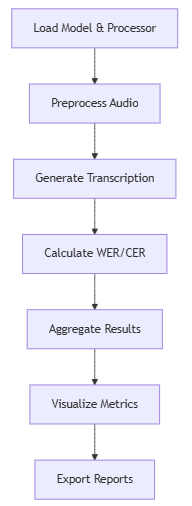

Step-by-Step Code Breakdown

Step 1: Model Initialization

    Loads Wav2Vec2 processor and model from Hugging Face Hub

    Configures GPU acceleration with FP16 precision

    Supports any Wav2Vec2 model identifier

Step 2: Audio Preprocessing

    Loads audio files using soundfile

    Converts stereo to mono by channel averaging

    Resamples to 16kHz using librosa if needed

    Handles variable sample rates automatically

Step 3: Transcription Pipeline

    Processes audio through Wav2Vec2 processor

    Runs inference with GPU-optimized FP16 tensors

    Decodes logits to text predictions

    Converts outputs to lowercase for case-insensitive comparison

Step 4: Error Metric Calculation

    Computes Word Error Rate (WER)

    Computes Character Error Rate (CER)

    Tracks metrics per sample and overall average

    Case-normalizes before comparison

Step 5: Visualization & Reporting

    Generates bar chart comparing average WER and CER

    Saves detailed results to CSV file:

        Audio file names

        Reference vs predicted transcripts

        Sample-specific error rates

    Prints summary statistics to console

Connecting to the Lecture

    Model Benchmarking: Demonstrates practical evaluation of ASR systems discussed in lecture

    Error Metrics: Implements standard WER/CER calculations for transcription accuracy

    Domain Adaptation: Tests models on custom audio types (lectures, conversations)

    Efficiency Practices: Uses FP16 precision and GPU acceleration

    Audio Preprocessing: Shows real-world handling of sample rate mismatches

    Reproducible Evaluation: CSV export enables result comparison across models

    Visual Communication: Bar chart simplifies performance comparison

    Flexible Framework: Supports benchmarking any Wav2Vec2 model

    Real Data Challenges: Processes actual user-provided audio files

    Error Analysis: Per-sample breakdown helps identify failure cases


In [1]:
# Install: pip install jiwer transformers evaluate soundfile matplotlib pandas librosa

import os
import torch
import soundfile as sf
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
import evaluate

AUDIO_DIR = r"C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\6 Evaluation Metrics and Benchmarking of SpeechLMs\6.2 Evaluation of Different Capabilities"
audio_files = [
    os.path.join(AUDIO_DIR, "lecture_segment1.wav"),
    os.path.join(AUDIO_DIR, "lecture_segment2.wav"),
    os.path.join(AUDIO_DIR, "conversation1.wav"),
    os.path.join(AUDIO_DIR, "technical_presentation.wav")
]

reference_texts = [
    "speech language models are transforming human computer interaction",
    "evaluation metrics like word error rate measure transcription accuracy",
    "please call Stella ask her to bring these things with her from the store",
    "convolutional neural networks and transformers form the basis of modern ASR systems"
]

def benchmark_custom_audio(model_id="facebook/wav2vec2-base-960h"):
    # 1. Load model and processor
    processor = Wav2Vec2Processor.from_pretrained(model_id)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = Wav2Vec2ForCTC.from_pretrained(model_id).to(device)
    if torch.cuda.is_available():
        model = model.half()  # FP16 for efficiency

    # 2. Initialize metrics
    wer_metric = evaluate.load("wer")
    cer_metric = evaluate.load("cer")

    # 3. Run benchmark on your audio files
    wer_scores, cer_scores = [], []
    sample_results = []

    for i, audio_path in enumerate(audio_files):
        print(f"Processing: {audio_path}")
        # Load audio
        audio, sr = sf.read(audio_path)
        if len(audio.shape) > 1:  # Stereo to mono
            audio = audio.mean(axis=1)
        # Resample if needed
        if sr != 16000:
            import librosa
            audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
            sr = 16000

        # Prepare input
        inputs = processor(
            audio=audio,
            sampling_rate=sr,
            return_tensors="pt",
            padding=True
        ).input_values.to(device)
        if torch.cuda.is_available():
            inputs = inputs.half()

        with torch.no_grad():
            logits = model(inputs).logits
            pred_ids = torch.argmax(logits, dim=-1)

        transcription = processor.batch_decode(pred_ids)[0].lower().strip()

        # Calculate metrics
        reference = reference_texts[i]
        wer = wer_metric.compute(references=[reference], predictions=[transcription])
        cer = cer_metric.compute(references=[reference], predictions=[transcription])

        wer_scores.append(wer)
        cer_scores.append(cer)
        sample_results.append({
            "file": os.path.basename(audio_path),
            "reference": reference,
            "prediction": transcription,
            "wer": wer,
            "cer": cer
        })

    # 4. Calculate overall metrics
    avg_wer = sum(wer_scores) / len(wer_scores)
    avg_cer = sum(cer_scores) / len(cer_scores)

    # 5. Visualization
    import matplotlib.pyplot as plt
    import pandas as pd

    # WER/CER comparison
    plt.figure(figsize=(10, 5))
    plt.bar(["WER", "CER"], [avg_wer*100, avg_cer*100], color=['#1f77b4', '#ff7f0e'])
    plt.ylabel("Error Rate (%)")
    plt.title(f"ASR Benchmark on Custom Audio ({model_id})")
    plt.grid(axis='y', alpha=0.3)
    plt.savefig("custom_audio_benchmark.png", dpi=120)
    plt.close()

    # Detailed results table
    df = pd.DataFrame(sample_results)
    df[["wer", "cer"]] = df[["wer", "cer"]] * 100
    df.to_csv("custom_audio_results.csv", index=False)

    # Print summary
    print("\n=== Custom Audio Benchmark Results ===")
    print(f"Average WER: {avg_wer*100:.2f}%")
    print(f"Average CER: {avg_cer*100:.2f}%")
    print(f"Sample results saved to custom_audio_results.csv")
    print(f"Visualization saved to custom_audio_benchmark.png")

    return {
        "wer": avg_wer,
        "cer": avg_cer,
        "samples": sample_results
    }

# Run benchmark
if __name__ == "__main__":
    benchmark_custom_audio()

C:\Users\vinit_hqjv9wt\anaconda3\envs\SpeechLM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Processing: C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\6 Evaluation Metrics and Benchmarking of SpeechLMs\6.2 Evaluation of Different Capabilities\lecture_segment1.wav


C:\Users\vinit_hqjv9wt\anaconda3\envs\SpeechLM\lib\site-packages\transformers\integrations\sdpa_attention.py:66: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


Processing: C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\6 Evaluation Metrics and Benchmarking of SpeechLMs\6.2 Evaluation of Different Capabilities\lecture_segment2.wav
Processing: C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\6 Evaluation Metrics and Benchmarking of SpeechLMs\6.2 Evaluation of Different Capabilities\conversation1.wav
Processing: C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\6 Evaluation Metrics and Benchmarking of SpeechLMs\6.2 Evaluation of Different Capabilities\technical_presentation.wav

=== Custom Audio Benchmark Results ===
Average WER: 41.07%
Average CER: 13.23%
Sample results saved to custom_audio_results.csv
Visualization saved to custom_audio_benchmark.png


### ASR Model Benchmarking on LibriSpeech

Title:
Whisper ASR Performance Evaluation on LibriSpeech Dataset

Short Description:
This code benchmarks the Whisper automatic speech recognition model on the LibriSpeech test-clean dataset. It demonstrates efficient evaluation practices by streaming audio samples, generating transcriptions, and calculating Word Error Rate (WER) - the standard metric for ASR system performance.

Key Libraries Used:

    transformers: ASR pipeline with Whisper model

    datasets: Streaming access to LibriSpeech benchmark

    evaluate: Word Error Rate (WER) metric computation

    torch: GPU acceleration and tensor operations

Code Logic and Flow

High-Level Overview:
The benchmark initializes a Whisper ASR model optimized for limited VRAM, streams samples from the LibriSpeech test set without full download, generates transcriptions with GPU acceleration, compares predictions to ground truth references, and calculates the overall Word Error Rate.

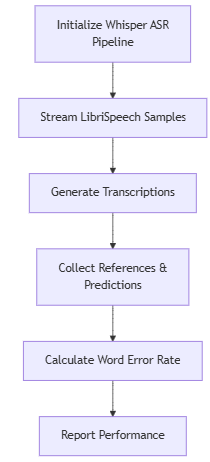

Step-by-Step Code Breakdown

Step 1: Model Initialization

    Checks GPU availability and selects device

    Loads Whisper-base.en model with safetensors support

    Configures FP16 precision for 6GB VRAM optimization

    Creates ASR pipeline ready for inference

Step 2: Dataset Handling

    Loads LibriSpeech test-clean split

    Uses streaming mode to avoid full dataset download

    Selects first 5 samples for demonstration

    Maintains original audio-reference pairing

Step 3: Transcription Process

    Processes each sample through ASR pipeline:

        Copies audio input to avoid modification

        Generates transcription via Whisper model

        Converts output to uppercase for case-insensitive comparison

        Preserves reference text for evaluation

Step 4: Performance Calculation

    Initializes WER metric from evaluate library

    Compares predictions to references:

        Case-normalized text comparison

        Alignment at word level

    Computes Word Error Rate percentage

Step 5: Results Reporting

    Prints sample-by-sample references vs predictions

    Displays overall WER score

    Includes interpretation guidance (lower WER = better)

    Maintains minimal resource usage throughout

Connecting to the Lecture

    Benchmarking Standards: Uses LibriSpeech - the industry standard ASR evaluation dataset

    Efficiency Practices: Demonstrates streaming for large datasets and FP16 for VRAM optimization

    Performance Metric: Implements Word Error Rate (WER) as discussed in evaluation lectures

    Model Selection: Uses Whisper architecture as representative modern ASR approach

    Resource Constraints: Addresses practical 6GB VRAM limitations

    Reproducible Evaluation: Provides template for consistent model comparison

    Error Analysis: Sample-by-sample output enables failure mode examination

    Practical Implementation: Shows end-to-best evaluation workflow from setup to metric reporting

    Accessibility: Works on both GPU and CPU environments

In [5]:
import torch
from datasets import load_dataset
from transformers import pipeline
import evaluate

# 1. Setup: Model and Device
# ---------------------------------
# Check for GPU availability
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load a pre-trained ASR pipeline. `transformers` will automatically download
# the model and use .safetensors by default if available.
# We use 'whisper-base.en' which is efficient and well-suited for a 6GB VRAM GPU.
# Adding `torch_dtype=torch.float16` can further reduce VRAM usage.
asr_pipeline = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base.en",
    torch_dtype=torch.float16,
    device=device,
)

# 2. Load the Benchmarking Dataset
# ---------------------------------
# We load the 'test.clean' split of LibriSpeech, a standard benchmark set.
# `streaming=True` is memory-efficient as it doesn't download the whole dataset at once.
librispeech_test = load_dataset(
    "librispeech_asr", "clean", split="test", streaming=True
)

# 3. Load the Evaluation Metric
# ---------------------------------
# Word Error Rate (WER) is the standard metric for ASR.
wer_metric = evaluate.load("wer")

# 4. Perform Benchmarking on a Few Samples
# ---------------------------------
# In a real benchmark, you'd iterate over the entire test set.
# For this example, we'll process 5 samples to demonstrate the concept.
num_samples_to_test = 5
samples = list(librispeech_test.take(num_samples_to_test))

# Store references and predictions for final WER calculation
references = [sample["text"] for sample in samples]
predictions = []

print("\n--- Running ASR Benchmark on LibriSpeech Samples ---")
for i, sample in enumerate(samples):
    audio_input = sample["audio"]
    reference_text = sample["text"]

    # Generate the transcription
    prediction_result = asr_pipeline(
        audio_input.copy() # Pass a copy to avoid in-place modification warnings
    )
    predicted_text = prediction_result["text"].upper().strip()
    predictions.append(predicted_text)
    
    print(f"\nSample {i+1}:")
    print(f"  Reference : {reference_text}")
    print(f"  Prediction: {predicted_text}")

# 5. Calculate and Report the Overall Metric
# ---------------------------------
# The `compute` method calculates the WER over all provided samples.
# In a real-world scenario, this would be computed over thousands of utterances.
wer_score = wer_metric.compute(predictions=predictions, references=references)

print("\n--- Benchmark Result ---")
print(f"Overall Word Error Rate (WER) on {num_samples_to_test} samples: {wer_score:.4f}")
print("A lower WER indicates better model performance.")

Using device: cuda:0


Device set to use cuda:0
Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.



--- Running ASR Benchmark on LibriSpeech Samples ---

Sample 1:
  Reference : CONCORD RETURNED TO ITS PLACE AMIDST THE TENTS
  Prediction: CONCORDE RETURNED TO ITS PLACE AMIDST THE TENTS.

Sample 2:
  Reference : THE ENGLISH FORWARDED TO THE FRENCH BASKETS OF FLOWERS OF WHICH THEY HAD MADE A PLENTIFUL PROVISION TO GREET THE ARRIVAL OF THE YOUNG PRINCESS THE FRENCH IN RETURN INVITED THE ENGLISH TO A SUPPER WHICH WAS TO BE GIVEN THE NEXT DAY
  Prediction: THE ENGLISH FORWARDED TO THE FRENCH BASKETS OF FLOWERS OF WHICH THEY HAD MADE A PLENTIFUL PROVISION TO GREET THE ARRIVAL OF THE YOUNG PRINCESS. THE FRENCH, IN RETURN, INVITED THE ENGLISH TO A SUPPER, WHICH WAS TO BE GIVEN THE NEXT DAY.

Sample 3:
  Reference : CONGRATULATIONS WERE POURED IN UPON THE PRINCESS EVERYWHERE DURING HER JOURNEY
  Prediction: CONGRATULATIONS WERE POURED IN UPON THE PRINCESS EVERYWHERE DURING HER JOURNEY.

Sample 4:
  Reference : FROM THE RESPECT PAID HER ON ALL SIDES SHE SEEMED LIKE A QUEEN AND FROM THE ADORAT